# Developer Journey

## Olivia

In [1]:
!pwd

/Users/oliviachoi/Documents/GitHub


In [6]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect("Spring2026_IndustryProject/developer_project.duckdb")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [ ]:
con.execute("""SHOW TABLES""").fetchdf()

,name
0,activity_base
1,activity_clean
2,activity_final
3,activity_raw
4,activity_score_mapping_clean
5,activity_score_mapping_raw
6,activity_work
7,contact_clean
8,contact_clean_backup_before_supplement
9,contact_final


In [ ]:
# unique activies from raw data
con.execute("""SELECT DISTINCT activity FROM activity_raw""").fetchdf()

,activity
0,Forum Contributions
1,"timeout-in-us = 4096 * (2**timeout)"""
2,Product Specific Comms
3,Event Registrations
4,Webinars
5,Model API
6,User Feedback
7,Brev
8,Bugs Filed
9,On-Demand Views


In [ ]:
# unique activity from cleaned dataset
con.execute("""SELECT DISTINCT activity FROM activity_final""").fetchdf()

,activity
0,dli training
1,contests
2,hackathons
3,devzone downloads
4,conference
5,on-demand views
6,bugs filed
7,conf. sessions live
8,forum contributions
9,program applications


In [ ]:
# IMPORTANT!
# ASSIGNING the 19 unique activies into a journey stage and an effort level
# Champion --> advocate (Community facing)
# Evaluate --> 
con.execute("""
CREATE OR REPLACE TABLE activity_journey_effort AS
SELECT * FROM (
    VALUES
        ('event registrations', 'Discover', 'low'),
        ('other events', 'Discover', 'low'),
        ('webinars', 'Discover', 'low'),
        ('brev', 'Discover', 'low'),
        ('dev program membership', 'Discover', 'medium'),

        ('dli training', 'Learn', 'medium'),
        ('on-demand views', 'Learn', 'low'),
        ('conf. sessions live', 'Learn', 'medium'),
        ('conference', 'Discover', 'medium'),

        ('devzone downloads', 'Evaluate', 'low'),
        ('ngc downloads', 'Evaluate', 'medium'),
        ('product specific comms', 'Evaluate', 'medium'),
        ('program applications', 'Evaluate', 'medium'),

        ('model api', 'Build', 'high'),
        ('hackathons', 'Build', 'high'),
        ('bugs filed', 'Build', 'high'),

        ('contests', 'Champion', 'high'),
        ('forum contributions', 'Champion', 'high'),
        ('user feedback', 'Champion', 'medium')
) AS t(activity, journey_stage, effort)
""").fetchdf()

,Count
0,19


In [35]:
# view spread of unique activies across our 5 stage (did not include dormant)
con.execute("""
SELECT
    journey_stage,
    effort,
    COUNT(*) AS unique_activity_count
FROM activity_journey_effort
GROUP BY journey_stage, effort
ORDER BY
    CASE journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
    END,
    CASE effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
    END
""").fetchdf()

,journey_stage,effort,unique_activity_count
0,Discover,medium,2
1,Discover,low,4
2,Learn,medium,2
3,Learn,low,1
4,Evaluate,medium,3
5,Evaluate,low,1
6,Build,high,3
7,Champion,high,2
8,Champion,medium,1


In [36]:
# apply journey stage mapping to full dataset and count total activities by stage
con.execute("""
SELECT
    aje.journey_stage,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END
""").fetchdf()

,journey_stage,total_activity_count
0,Discover,7628593
1,Learn,4687203
2,Evaluate,48425054
3,Build,6582579
4,Champion,2024072


In [37]:
# apply journey stage and effort mapping to full dataset
con.execute("""
SELECT
    aje.journey_stage,
    aje.effort,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage, aje.effort
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END,
    CASE aje.effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
        ELSE 4
    END
""").fetchdf()

,journey_stage,effort,total_activity_count
0,Discover,medium,7169043
1,Discover,low,459550
2,Learn,medium,3246617
3,Learn,low,1440586
4,Evaluate,medium,8682460
5,Evaluate,low,39742594
6,Build,high,6582579
7,Champion,high,785496
8,Champion,medium,1238576


In [38]:
# check unmapped activities
con.execute("""
SELECT
    af.activity,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
WHERE aje.journey_stage IS NULL
GROUP BY af.activity
ORDER BY total_activity_count DESC
""").fetchdf()

,activity,total_activity_count


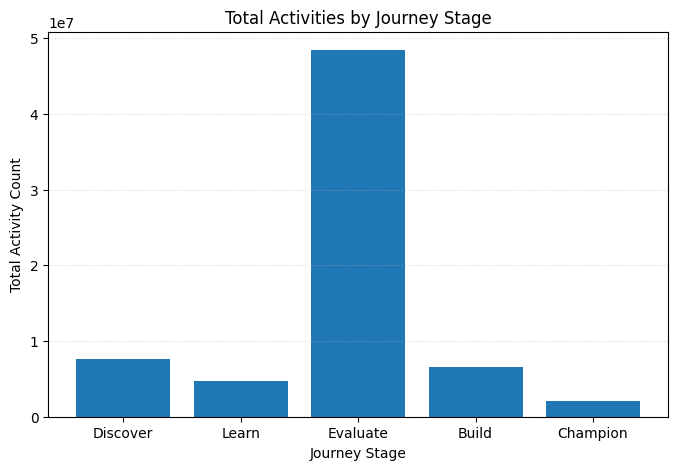

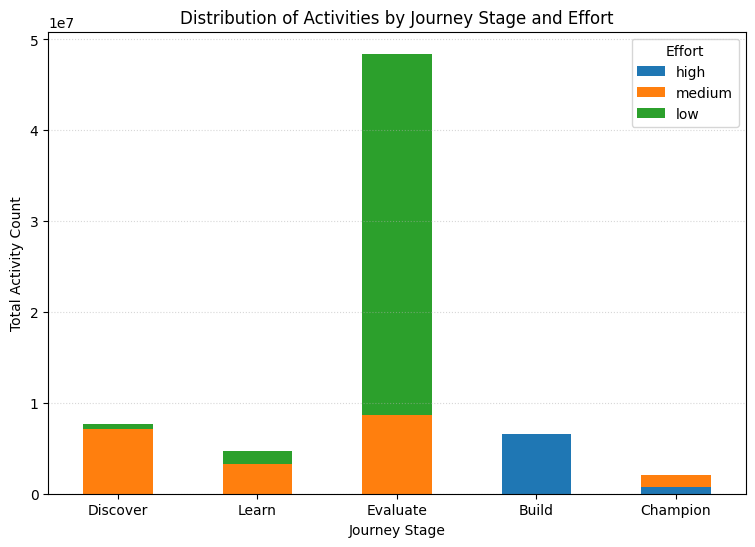

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# get counts by journey stage and effort from full dataset
stageEffortDf = con.execute("""
SELECT
    aje.journey_stage,
    aje.effort,
    COUNT(*) AS total_activity_count
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
GROUP BY aje.journey_stage, aje.effort
ORDER BY
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
        ELSE 6
    END,
    CASE aje.effort
        WHEN 'high' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'low' THEN 3
        ELSE 4
    END
""").fetchdf()

# total by stage
stageTotalDf = (
    stageEffortDf.groupby("journey_stage", as_index=False)["total_activity_count"]
    .sum()
)

stageOrder = ["Discover", "Learn", "Evaluate", "Build", "Champion"]
effortOrder = ["high", "medium", "low"]

stageTotalDf["journey_stage"] = pd.Categorical(
    stageTotalDf["journey_stage"],
    categories=stageOrder,
    ordered=True
)
stageTotalDf = stageTotalDf.sort_values("journey_stage")

# graph 1: total activities by stage
plt.figure(figsize=(8,5))
plt.bar(stageTotalDf["journey_stage"], stageTotalDf["total_activity_count"])
plt.title("Total Activities by Journey Stage")
plt.xlabel("Journey Stage")
plt.ylabel("Total Activity Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.show()

# reshape for stacked bar chart
pivotDf = stageEffortDf.pivot(
    index="journey_stage",
    columns="effort",
    values="total_activity_count"
).fillna(0)

pivotDf = pivotDf.reindex(stageOrder)
pivotDf = pivotDf.reindex(columns=effortOrder)

# graph 2: stacked bar chart by stage and effort
pivotDf.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6)
)
plt.title("Distribution of Activities by Journey Stage and Effort")
plt.xlabel("Journey Stage")
plt.ylabel("Total Activity Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.legend(title="Effort")
plt.show()

In [42]:
# create enriched activity table with journey stage and effort
con.execute("""
CREATE OR REPLACE TABLE activity_enriched AS
SELECT
    af.*,
    aje.journey_stage,
    aje.effort,
    CASE aje.journey_stage
        WHEN 'Discover' THEN 1
        WHEN 'Learn' THEN 2
        WHEN 'Evaluate' THEN 3
        WHEN 'Build' THEN 4
        WHEN 'Champion' THEN 5
    END AS journey_stage_num,
    CASE aje.effort
        WHEN 'low' THEN 1
        WHEN 'medium' THEN 2
        WHEN 'high' THEN 3
    END AS effort_score
FROM activity_final af
LEFT JOIN activity_journey_effort aje
    ON af.activity = aje.activity
""")

100% ▕██████████████████████████████████████▏ (00:00:43.30 elapsed)     


In [ ]:
# developer-level journey score
# should journey stage num be highest historically or current
developerScoreDf = con.execute("""
SELECT
    dev_contact,
    COUNT(*) AS total_activities,
    COUNT(DISTINCT activity) AS unique_activities,
    COUNT(DISTINCT journey_stage) AS stages_touched,
    MAX(journey_stage_num) AS highest_stage_num,
    AVG(journey_stage_num) AS avg_stage_score,
    AVG(effort_score) AS avg_effort_score,
    SUM(journey_stage_num * effort_score) AS weighted_engagement_score
FROM activity_enriched
GROUP BY dev_contact
ORDER BY weighted_engagement_score DESC
""").fetchdf()

developerScoreDf.head()

100% ▕██████████████████████████████████████▏ (00:00:30.14 elapsed)       


,dev_contact,total_activities,unique_activities,stages_touched,highest_stage_num,avg_stage_score,avg_effort_score,weighted_engagement_score
0,5903679,2027375,2,2,3,2.999999,2.000000,12164246.0
1,5886356,789400,4,2,3,2.999992,1.999999,4736385.0
2,3931685,187095,1,1,3,3.000000,2.000000,1122570.0
3,2028858,142980,1,1,3,3.000000,2.000000,857880.0
4,6309430,121950,5,3,4,3.000722,1.995457,730316.0


In [ ]:
# assign developer segment based on behavior
# can change power champion
developerSegmentDf = con.execute("""
WITH developer_summary AS (
    SELECT
        dev_contact,
        COUNT(*) AS total_activities,
        COUNT(DISTINCT activity) AS unique_activities,
        COUNT(DISTINCT journey_stage) AS stages_touched,
        MAX(journey_stage_num) AS highest_stage_num,
        SUM(journey_stage_num * effort_score) AS weighted_engagement_score
    FROM activity_enriched
    GROUP BY dev_contact
)

SELECT
    *,
    CASE
        WHEN highest_stage_num = 5 AND weighted_engagement_score >= 50 THEN 'Power Champion'
        WHEN highest_stage_num = 5 THEN 'Community Champion'
        WHEN highest_stage_num = 4 THEN 'Builder'
        WHEN highest_stage_num = 3 THEN 'Evaluator'
        WHEN highest_stage_num = 2 THEN 'Learner'
        WHEN highest_stage_num = 1 THEN 'Discoverer'
        ELSE 'Unclassified'
    END AS developer_segment
FROM developer_summary
ORDER BY weighted_engagement_score DESC
""").fetchdf()

developerSegmentDf.head()

100% ▕██████████████████████████████████████▏ (00:00:11.76 elapsed)     


,dev_contact,total_activities,unique_activities,stages_touched,highest_stage_num,weighted_engagement_score,developer_segment
0,5903679,2027375,2,2,3,12164246.0,Evaluator
1,5886356,789400,4,2,3,4736385.0,Evaluator
2,3931685,187095,1,1,3,1122570.0,Evaluator
3,2028858,142980,1,1,3,857880.0,Evaluator
4,6309430,121950,5,3,4,730316.0,Builder


In [54]:
developerSegmentDf.groupby("developer_segment").size().reset_index(name="developer_count")

,developer_segment,developer_count
0,Builder,262584
1,Community Champion,824471
2,Discoverer,1548537
3,Evaluator,3497467
4,Learner,1299927
5,Power Champion,227292


In [55]:
# funnel: number of developers reaching each stage
funnelDf = con.execute("""
SELECT
    journey_stage,
    journey_stage_num,
    COUNT(DISTINCT dev_contact) AS developer_count
FROM activity_enriched
GROUP BY journey_stage, journey_stage_num
ORDER BY journey_stage_num
""").fetchdf()

funnelDf

,journey_stage,journey_stage_num,developer_count
0,Discover,1,6689900
1,Learn,2,1574211
2,Evaluate,3,4510789
3,Build,4,274927
4,Champion,5,1051763


In [ ]:
# funnel conversion rate from Discover
# with these, do we want to redefine our "score" from rarest to least rare (5-1)
discoverCount = funnelDf.loc[funnelDf["journey_stage"] == "Discover", "developer_count"].iloc[0]

funnelDf["conversion_from_discover"] = funnelDf["developer_count"] / discoverCount

funnelDf

,journey_stage,journey_stage_num,developer_count,conversion_from_discover
0,Discover,1,6689900,1.000000
1,Learn,2,1574211,0.235312
2,Evaluate,3,4510789,0.674269
3,Build,4,274927,0.041096
4,Champion,5,1051763,0.157217


In [58]:
# view stage transitions over time
transitionDf = con.execute("""
WITH ordered_activities AS (
    SELECT
        dev_contact,
        activity_date,
        journey_stage,
        journey_stage_num,
        LEAD(journey_stage) OVER (
            PARTITION BY dev_contact
            ORDER BY activity_date
        ) AS next_journey_stage,
        LEAD(journey_stage_num) OVER (
            PARTITION BY dev_contact
            ORDER BY activity_date
        ) AS next_journey_stage_num
    FROM activity_enriched
)

SELECT
    journey_stage AS from_stage,
    next_journey_stage AS to_stage,
    COUNT(*) AS transition_count
FROM ordered_activities
WHERE next_journey_stage IS NOT NULL
GROUP BY from_stage, to_stage
ORDER BY transition_count DESC
""").fetchdf()

transitionDf

100% ▕██████████████████████████████████████▏ (00:00:03.68 elapsed)     


,from_stage,to_stage,transition_count
0,Evaluate,Evaluate,41952524
1,Build,Build,6193882
2,Learn,Learn,2762664
3,Discover,Evaluate,2662164
4,Evaluate,Discover,2110666
5,Discover,Learn,1033420
6,Champion,Evaluate,928393
7,Evaluate,Champion,844485
8,Learn,Discover,668057
9,Champion,Champion,634347


In [60]:
# identify where developers stop
dropoffDf = con.execute("""
WITH developer_max_stage AS (
    SELECT
        dev_contact,
        MAX(journey_stage_num) AS max_stage_num
    FROM activity_enriched
    GROUP BY dev_contact
)

SELECT
    CASE max_stage_num
        WHEN 1 THEN 'Discover'
        WHEN 2 THEN 'Learn'
        WHEN 3 THEN 'Evaluate'
        WHEN 4 THEN 'Build'
        WHEN 5 THEN 'Champion'
    END AS final_stage,
    COUNT(*) AS developer_count
FROM developer_max_stage
GROUP BY final_stage, max_stage_num
ORDER BY max_stage_num
""").fetchdf()

dropoffDf

,final_stage,developer_count
0,Discover,1548537
1,Learn,1299927
2,Evaluate,3497467
3,Build,262584
4,Champion,1051763


In [63]:
# common journey paths by developer, memory-safe version
pathDf = con.execute("""
WITH first_stage AS (
    SELECT
        dev_contact,
        journey_stage,
        journey_stage_num,
        MIN(activity_date) AS first_stage_date
    FROM activity_enriched
    WHERE journey_stage IS NOT NULL
    GROUP BY dev_contact, journey_stage, journey_stage_num
),

paths AS (
    SELECT
        dev_contact,
        STRING_AGG(journey_stage, ' -> ' ORDER BY first_stage_date, journey_stage_num) AS journey_path
    FROM first_stage
    GROUP BY dev_contact
)

SELECT
    journey_path,
    COUNT(*) AS developer_count
FROM paths
GROUP BY journey_path
ORDER BY developer_count DESC
LIMIT 20
""").fetchdf()

pathDf

100% ▕██████████████████████████████████████▏ (00:00:10.34 elapsed)     


,journey_path,developer_count
0,Discover -> Evaluate,2688208
1,Discover,1548537
2,Discover -> Learn,1140815
3,Discover -> Evaluate -> Champion,713800
4,Evaluate,593638
5,Discover -> Build,154010
6,Evaluate -> Champion,136921
7,Learn,128222
8,Discover -> Learn -> Evaluate,68815
9,Discover -> Evaluate -> Learn,58870


In [65]:
# high effort concentration by developer
highEffortDf = con.execute("""
SELECT
    dev_contact,
    COUNT(*) AS high_effort_activity_count
FROM activity_enriched
WHERE effort = 'high'
GROUP BY dev_contact
ORDER BY high_effort_activity_count DESC
""").fetchdf()

highEffortDf.head(20)

,dev_contact,high_effort_activity_count
0,812707,36853
1,6502867,36747
2,7938574,20695
3,8582183,19294
4,6590114,18224
5,5944779,17144
6,5944795,15477
7,6149082,15027
8,9633953,12604
9,6522695,12015


In [66]:
# percent of high-effort activity from top developers
highEffortDf["cum_high_effort"] = highEffortDf["high_effort_activity_count"].cumsum()
highEffortDf["total_high_effort"] = highEffortDf["high_effort_activity_count"].sum()
highEffortDf["cum_percent"] = highEffortDf["cum_high_effort"] / highEffortDf["total_high_effort"]

highEffortDf.head(20)

,dev_contact,high_effort_activity_count,cum_high_effort,total_high_effort,cum_percent
0,812707,36853,36853,7368075,0.005002
1,6502867,36747,73600,7368075,0.009989
2,7938574,20695,94295,7368075,0.012798
3,8582183,19294,113589,7368075,0.015416
4,6590114,18224,131813,7368075,0.017890
5,5944779,17144,148957,7368075,0.020217
6,5944795,15477,164434,7368075,0.022317
7,6149082,15027,179461,7368075,0.024357
8,9633953,12604,192065,7368075,0.026067
9,6522695,12015,204080,7368075,0.027698


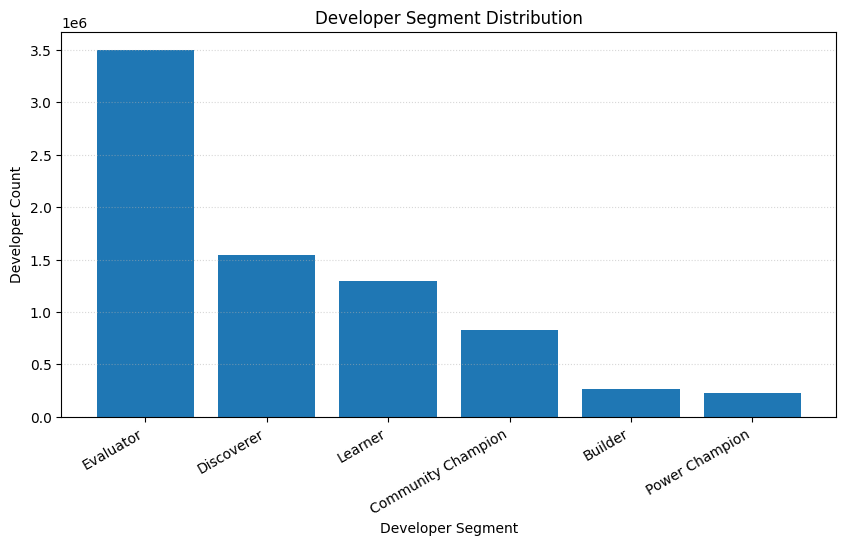

In [67]:
import matplotlib.pyplot as plt

# graph developer segment distribution
segmentCounts = (
    developerSegmentDf.groupby("developer_segment")
    .size()
    .reset_index(name="developer_count")
    .sort_values("developer_count", ascending=False)
)

plt.figure(figsize=(10,5))
plt.bar(segmentCounts["developer_segment"], segmentCounts["developer_count"])
plt.title("Developer Segment Distribution")
plt.xlabel("Developer Segment")
plt.ylabel("Developer Count")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="dotted", alpha=0.5)
plt.show()

## Dormant Developers

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DB_PATH = "developer_project.duckdb"

# Sampling and threshold parameters
SAMPLE_MODULUS = 1000
SAMPLE_CUTOFF = 5      # about 0.5% of developers; increase slowly if needed
AT_RISK_DAYS = 56      # 8 weeks
DORMANT_DAYS = 84      # 12 weeks
FUTURE_RETURN_WEEKS = 8
PLOT_MAX_GAP_DAYS = 180

con = duckdb.connect(DB_PATH)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

print("Connected to:", DB_PATH)
display(con.execute("SHOW TABLES").fetchdf())


Connected to: developer_project.duckdb


,name
0,activity_base
1,activity_clean
2,activity_enriched
3,activity_final
4,activity_journey_effort
5,activity_ontology_v1
6,activity_raw
7,activity_score_mapping_clean
8,activity_score_mapping_raw
9,activity_work


In [2]:
con.execute("""
CREATE OR REPLACE TABLE activity_journey_effort AS
SELECT * FROM (
    VALUES
        ('event registrations',    'Discover', 'low'),
        ('event registration',     'Discover', 'low'),
        ('other events',           'Discover', 'low'),
        ('webinars',               'Discover', 'low'),
        ('brev',                   'Discover', 'low'),
        ('dev program membership', 'Discover', 'medium'),
        ('conference',             'Discover', 'medium'),

        ('dli training',           'Learn',    'medium'),
        ('on-demand views',        'Learn',    'low'),
        ('conf. sessions live',    'Learn',    'medium'),

        ('devzone downloads',      'Evaluate', 'low'),
        ('ngc downloads',          'Evaluate', 'medium'),
        ('product specific comms', 'Evaluate', 'medium'),
        ('program applications',   'Evaluate', 'medium'),

        ('model api',              'Build',    'high'),
        ('hosted api',             'Build',    'high'),
        ('hackathons',             'Build',    'high'),
        ('hackathon',              'Build',    'high'),
        ('bugs filed',             'Build',    'high'),

        ('contests',               'Champion', 'high'),
        ('forum contributions',    'Champion', 'high'),
        ('user feedback',          'Champion', 'medium'),
        ('user feedback forms',    'Champion', 'medium')
) AS t(activity, journey_stage, effort)
""")

coverage = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN m.activity IS NOT NULL THEN 1 ELSE 0 END) AS mapped_rows,
    SUM(CASE WHEN m.activity IS NULL THEN 1 ELSE 0 END) AS unmapped_rows,
    ROUND(
        100.0 * SUM(CASE WHEN m.activity IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS pct_mapped
FROM activity_clean a
LEFT JOIN activity_journey_effort m
  ON lower(trim(a.activity)) = m.activity
WHERE a.activity IS NOT NULL
""").fetchdf()

unmapped = con.execute("""
SELECT
    lower(trim(a.activity)) AS unmapped_activity,
    COUNT(*) AS rows
FROM activity_clean a
LEFT JOIN activity_journey_effort m
  ON lower(trim(a.activity)) = m.activity
WHERE a.activity IS NOT NULL
  AND m.activity IS NULL
GROUP BY 1
ORDER BY rows DESC
""").fetchdf()

mapped_distribution = con.execute("""
SELECT
    m.journey_stage,
    m.effort,
    COUNT(*) AS rows
FROM activity_clean a
JOIN activity_journey_effort m
  ON lower(trim(a.activity)) = m.activity
GROUP BY 1, 2
ORDER BY rows DESC
""").fetchdf()

print("Mapping coverage")
display(coverage)

print("Top unmapped activities")
display(unmapped.head(50))

print("Mapped activity distribution")
display(mapped_distribution)


Mapping coverage


,total_rows,mapped_rows,unmapped_rows,pct_mapped
0,69347526,69347523.0,3.0,100.0


Top unmapped activities


,unmapped_activity,rows
0,i want to know how this feature can be manipul...,1
1,during soft link creation in setting up the nv...,1
2,"timeout-in-us = 4096 * (2**timeout)""",1


Mapped activity distribution


,journey_stage,effort,rows
0,Evaluate,low,39742594
1,Evaluate,medium,8682477
2,Discover,medium,7169043
3,Build,high,6582579
4,Learn,medium,3246617
5,Learn,low,1440586
6,Champion,medium,1238576
7,Champion,high,785499
8,Discover,low,459552


In [3]:
con.execute(f"""
CREATE OR REPLACE TABLE dev_sample AS
SELECT developer_id
FROM (
    SELECT DISTINCT dev_contact AS developer_id
    FROM activity_clean
    WHERE dev_contact IS NOT NULL
) d
WHERE mod(hash(developer_id), {SAMPLE_MODULUS}) < {SAMPLE_CUTOFF}
""")

con.execute("""
CREATE OR REPLACE TABLE activity_sample AS
SELECT a.*
FROM activity_clean a
JOIN dev_sample d
  ON a.dev_contact = d.developer_id
""")

con.execute("""
CREATE OR REPLACE TABLE contact_sample AS
SELECT c.*
FROM contact_clean c
JOIN dev_sample d
  ON c.developer_id = d.developer_id
""")

sample_counts = con.execute("""
SELECT 'dev_sample' AS table_name, COUNT(*) AS rows FROM dev_sample
UNION ALL
SELECT 'activity_sample', COUNT(*) FROM activity_sample
UNION ALL
SELECT 'contact_sample', COUNT(*) FROM contact_sample
""").fetchdf()

display(sample_counts)


100% ▕██████████████████████████████████████▏ (00:00:03.08 elapsed)     


,table_name,rows
0,dev_sample,38418
1,activity_sample,386298
2,contact_sample,38417


In [4]:
con.execute("""
CREATE OR REPLACE TABLE sample_events_v1 AS
WITH base AS (
    SELECT
        a.dev_contact AS developer_id,
        CAST(a.activity_date AS DATE) AS activity_day,
        CAST(date_trunc('week', CAST(a.activity_date AS DATE)) AS DATE) AS week_start,
        lower(trim(a.activity)) AS activity,
        a.activity_name,
        m.journey_stage,
        lower(m.effort) AS effort,
        coalesce(
            nullif(a.activity_id, ''),
            nullif(a.pk1, ''),
            nullif(a.pk2, ''),
            md5(
                coalesce(a.dev_contact, '') || '|' ||
                coalesce(lower(trim(a.activity)), '') || '|' ||
                coalesce(lower(trim(a.activity_name)), '') || '|' ||
                coalesce(lower(trim(a.activity_type)), '') || '|' ||
                coalesce(lower(trim(a.activity_role)), '') || '|' ||
                coalesce(lower(trim(a.activity_attendance)), '') || '|' ||
                coalesce(lower(trim(a.filepath)), '') || '|' ||
                coalesce(CAST(CAST(a.activity_date AS DATE) AS VARCHAR), '')
            )
        ) AS canonical_event_key
    FROM activity_sample a
    JOIN activity_journey_effort m
      ON lower(trim(a.activity)) = m.activity
    WHERE a.dev_contact IS NOT NULL
      AND a.activity_date IS NOT NULL
),
deduped AS (
    SELECT
        developer_id,
        activity_day,
        week_start,
        activity,
        activity_name,
        journey_stage,
        effort,
        canonical_event_key
    FROM (
        SELECT
            *,
            row_number() OVER (
                PARTITION BY developer_id, activity, canonical_event_key
                ORDER BY activity_day
            ) AS rn
        FROM base
    ) x
    WHERE rn = 1
)
SELECT *
FROM deduped
""")

dedupe_check = con.execute("""
WITH raw_joined AS (
    SELECT
        a.dev_contact AS developer_id,
        coalesce(
            nullif(a.activity_id, ''),
            nullif(a.pk1, ''),
            nullif(a.pk2, ''),
            md5(
                coalesce(a.dev_contact, '') || '|' ||
                coalesce(lower(trim(a.activity)), '') || '|' ||
                coalesce(lower(trim(a.activity_name)), '') || '|' ||
                coalesce(lower(trim(a.activity_type)), '') || '|' ||
                coalesce(lower(trim(a.activity_role)), '') || '|' ||
                coalesce(lower(trim(a.activity_attendance)), '') || '|' ||
                coalesce(lower(trim(a.filepath)), '') || '|' ||
                coalesce(CAST(CAST(a.activity_date AS DATE) AS VARCHAR), '')
            )
        ) AS canonical_event_key
    FROM activity_sample a
    JOIN activity_journey_effort m
      ON lower(trim(a.activity)) = m.activity
    WHERE a.dev_contact IS NOT NULL
      AND a.activity_date IS NOT NULL
)
SELECT 'raw_joined' AS stage, COUNT(*) AS rows FROM raw_joined
UNION ALL
SELECT 'deduped' AS stage, COUNT(*) AS rows FROM sample_events_v1
""").fetchdf()

stage_counts = con.execute("""
SELECT
    journey_stage,
    effort,
    COUNT(*) AS rows
FROM sample_events_v1
GROUP BY 1, 2
ORDER BY rows DESC
""").fetchdf()

display(dedupe_check)
display(stage_counts)


,stage,rows
0,raw_joined,386298
1,deduped,384925


,journey_stage,effort,rows
0,Evaluate,low,198934
1,Evaluate,medium,90468
2,Discover,medium,36124
3,Build,high,26944
4,Learn,medium,14750
5,Learn,low,6615
6,Champion,medium,6264
7,Discover,low,2523
8,Champion,high,2303


In [5]:
con.execute("""
CREATE OR REPLACE TABLE dev_weekly_activity_v1 AS
WITH weekly AS (
    SELECT
        developer_id,
        week_start,
        COUNT(*) AS mapped_events,
        COUNT(DISTINCT activity_day) AS active_days,
        SUM(CASE WHEN journey_stage = 'Build' THEN 1 ELSE 0 END) AS build_events,
        SUM(CASE WHEN journey_stage = 'Champion' THEN 1 ELSE 0 END) AS champion_events,
        SUM(CASE WHEN effort IN ('medium', 'high') THEN 1 ELSE 0 END) AS medium_high_events,
        COUNT(DISTINCT CASE
            WHEN journey_stage IN ('Learn', 'Evaluate') AND effort = 'low'
            THEN activity_day
        END) AS low_eval_learn_days
    FROM sample_events_v1
    GROUP BY 1, 2
)
SELECT
    *,
    CASE
        WHEN build_events + champion_events > 0 THEN 1 ELSE 0
    END AS buildish_week,
    CASE
        WHEN build_events + champion_events > 0 THEN 1
        WHEN medium_high_events > 0 THEN 1
        WHEN low_eval_learn_days >= 2 THEN 1
        ELSE 0
    END AS meaningful_active_week
FROM weekly
""")

weekly_preview = con.execute("""
SELECT *
FROM dev_weekly_activity_v1
ORDER BY developer_id, week_start
LIMIT 20
""").fetchdf()

weekly_counts = con.execute("""
SELECT
    SUM(meaningful_active_week) AS meaningful_active_weeks,
    SUM(buildish_week) AS buildish_weeks
FROM dev_weekly_activity_v1
""").fetchdf()

display(weekly_preview)
display(weekly_counts)


,developer_id,week_start,mapped_events,active_days,build_events,champion_events,medium_high_events,low_eval_learn_days,buildish_week,meaningful_active_week
0,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-07-21,1,1,0.0,0.0,1.0,0,0,1
1,07742c3ba36073dfff645bbb596aef538adb11a153f01c...,2026-02-02,1,1,0.0,0.0,1.0,0,0,1
2,0966991d080463e77fb21bdbb244871a89c262325a0737...,2025-07-07,1,1,0.0,0.0,1.0,0,0,1
3,09969d75d8970fcf4190944b4fcc028436294dd84ef7bc...,2026-02-09,1,1,0.0,0.0,1.0,0,0,1
4,0a6f09efea6ffd6dafeb7e9db4722f2b0d599622fd6187...,2025-08-18,1,1,0.0,0.0,1.0,0,0,1
5,0bc62650112e4d9d3527ab8c3a237c02c882e3dc8cf1dc...,2025-12-08,1,1,0.0,0.0,1.0,0,0,1
6,0dde9985476c5514064ccdbd85a3d6c973db61a6ffc26f...,2025-07-14,1,1,0.0,0.0,1.0,0,0,1
7,10000064,2026-01-05,5,1,4.0,0.0,5.0,0,1,1
8,10000064,2026-01-12,8,3,8.0,0.0,8.0,0,1,1
9,10000064,2026-01-26,4,2,4.0,0.0,4.0,0,1,1


,meaningful_active_weeks,buildish_weeks
0,53973.0,11519.0


In [6]:
con.execute("""
CREATE OR REPLACE TABLE sample_dev_bounds_v1 AS
SELECT
    developer_id,
    MIN(week_start) AS first_week,
    MAX(week_start) AS last_week
FROM sample_events_v1
GROUP BY 1
""")

con.execute("""
CREATE OR REPLACE TABLE week_spine_v1 AS
WITH bounds AS (
    SELECT
        MIN(week_start) AS min_week,
        MAX(week_start) AS max_week
    FROM sample_events_v1
)
SELECT CAST(week_start AS DATE) AS week_start
FROM bounds,
generate_series(min_week, max_week, interval '7 days') AS t(week_start)
""")

con.execute(f"""
CREATE OR REPLACE TABLE dev_week_status_v1 AS
WITH global_bounds AS (
    SELECT MAX(week_start) AS max_week
    FROM week_spine_v1
),
grid AS (
    SELECT
        b.developer_id,
        w.week_start
    FROM sample_dev_bounds_v1 b
    JOIN week_spine_v1 w
      ON w.week_start >= b.first_week
    JOIN global_bounds g
      ON w.week_start <= g.max_week
),
joined AS (
    SELECT
        g.developer_id,
        g.week_start,
        COALESCE(a.buildish_week, 0) AS buildish_week,
        COALESCE(a.meaningful_active_week, 0) AS meaningful_active_week
    FROM grid g
    LEFT JOIN dev_weekly_activity_v1 a
      USING (developer_id, week_start)
),
scored AS (
    SELECT
        *,
        SUM(meaningful_active_week) OVER (
            PARTITION BY developer_id
            ORDER BY week_start
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS lifetime_meaningful_active_weeks,
        MAX(CASE WHEN meaningful_active_week = 1 THEN week_start END) OVER (
            PARTITION BY developer_id
            ORDER BY week_start
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS last_meaningful_week,
        MAX(meaningful_active_week) OVER (
            PARTITION BY developer_id
            ORDER BY week_start
            ROWS BETWEEN 1 FOLLOWING AND {FUTURE_RETURN_WEEKS} FOLLOWING
        ) AS returns_next_8w_meaningful,
        MAX(buildish_week) OVER (
            PARTITION BY developer_id
            ORDER BY week_start
            ROWS BETWEEN 1 FOLLOWING AND {FUTURE_RETURN_WEEKS} FOLLOWING
        ) AS returns_next_8w_buildish
    FROM joined
)
SELECT
    *,
    date_diff('day', last_meaningful_week, week_start) AS days_since_last_meaningful
FROM scored
""")

status_preview = con.execute("""
SELECT *
FROM dev_week_status_v1
ORDER BY developer_id, week_start
LIMIT 30
""").fetchdf()

status_summary = con.execute("""
SELECT
    COUNT(*) AS developer_week_rows,
    COUNT(DISTINCT developer_id) AS developers,
    MIN(week_start) AS first_week,
    MAX(week_start) AS last_week
FROM dev_week_status_v1
""").fetchdf()

display(status_preview)
display(status_summary)


,developer_id,week_start,buildish_week,meaningful_active_week,lifetime_meaningful_active_weeks,last_meaningful_week,returns_next_8w_meaningful,returns_next_8w_buildish,days_since_last_meaningful
0,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-07-21,0,1,1.0,2025-07-21,0,0,0
1,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-07-28,0,0,1.0,2025-07-21,0,0,7
2,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-08-04,0,0,1.0,2025-07-21,0,0,14
3,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-08-11,0,0,1.0,2025-07-21,0,0,21
4,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-08-18,0,0,1.0,2025-07-21,0,0,28
5,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-08-25,0,0,1.0,2025-07-21,0,0,35
6,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-09-01,0,0,1.0,2025-07-21,0,0,42
7,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-09-08,0,0,1.0,2025-07-21,0,0,49
8,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-09-15,0,0,1.0,2025-07-21,0,0,56
9,05b081360cc877c03cb0002ad6498d96848043acd1bc10...,2025-09-22,0,0,1.0,2025-07-21,0,0,63


,developer_week_rows,developers,first_week,last_week
0,5208808,38418,2019-12-30,2026-03-09


In [7]:
con.execute("""
CREATE OR REPLACE TABLE meaningful_gap_dist_v1 AS
WITH seq AS (
    SELECT
        developer_id,
        week_start,
        lag(week_start) OVER (
            PARTITION BY developer_id
            ORDER BY week_start
        ) AS prev_week
    FROM dev_week_status_v1
    WHERE meaningful_active_week = 1
)
SELECT
    developer_id,
    date_diff('day', prev_week, week_start) AS gap_days
FROM seq
WHERE prev_week IS NOT NULL
""")

gap_summary = con.execute("""
SELECT
    COUNT(*) AS gap_count,
    quantile_cont(gap_days, 0.50) AS p50_gap_days,
    quantile_cont(gap_days, 0.75) AS p75_gap_days,
    quantile_cont(gap_days, 0.90) AS p90_gap_days,
    quantile_cont(gap_days, 0.95) AS p95_gap_days
FROM meaningful_gap_dist_v1
WHERE gap_days <= 365
""").fetchdf()

con.execute("""
CREATE OR REPLACE TABLE recency_curve_meaningful_v1 AS
SELECT
    CAST(floor(days_since_last_meaningful / 14.0) * 14 AS INTEGER) AS recency_bin_days,
    COUNT(*) AS snapshots,
    AVG(COALESCE(returns_next_8w_meaningful, 0)) AS return_rate_next_8w,
    AVG(COALESCE(returns_next_8w_buildish, 0)) AS buildish_return_rate_next_8w
FROM dev_week_status_v1
WHERE lifetime_meaningful_active_weeks >= 2
  AND days_since_last_meaningful IS NOT NULL
  AND returns_next_8w_meaningful IS NOT NULL
GROUP BY 1
HAVING COUNT(*) >= 50
ORDER BY 1
""")

con.execute(f"""
CREATE OR REPLACE TABLE threshold_eval_v1 AS
WITH base AS (
    SELECT *
    FROM dev_week_status_v1
    WHERE week_start <= (
        SELECT MAX(week_start) - interval '{FUTURE_RETURN_WEEKS * 7} days'
        FROM dev_week_status_v1
    )
),
thresholds AS (
    SELECT * FROM (
        VALUES
            ('8w', 56),
            ('12w', 84),
            ('16w', 112)
    ) AS t(threshold, days_cutoff)
)
SELECT
    t.threshold,
    COUNT(*) AS labeled_snapshots,
    AVG(COALESCE(b.returns_next_8w_meaningful, 0)) AS return_rate_next_8w,
    AVG(COALESCE(b.returns_next_8w_buildish, 0)) AS buildish_return_rate_next_8w
FROM base b
JOIN thresholds t
  ON b.days_since_last_meaningful >= t.days_cutoff
WHERE b.lifetime_meaningful_active_weeks >= 2
GROUP BY 1
ORDER BY 1
""")

con.execute("""
CREATE OR REPLACE TABLE current_threshold_population_v1 AS
WITH latest_snapshot AS (
    SELECT *
    FROM dev_week_status_v1
    WHERE week_start = (SELECT MAX(week_start) FROM dev_week_status_v1)
),
thresholds AS (
    SELECT * FROM (
        VALUES
            ('8w', 56),
            ('12w', 84),
            ('16w', 112)
    ) AS t(threshold, days_cutoff)
)
SELECT
    t.threshold,
    SUM(CASE WHEN s.lifetime_meaningful_active_weeks >= 2 THEN 1 ELSE 0 END) AS eligible_developers,
    SUM(CASE WHEN s.lifetime_meaningful_active_weeks >= 2 AND s.days_since_last_meaningful >= t.days_cutoff THEN 1 ELSE 0 END) AS labeled_dormant,
    ROUND(
        100.0 * SUM(CASE WHEN s.lifetime_meaningful_active_weeks >= 2 AND s.days_since_last_meaningful >= t.days_cutoff THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN s.lifetime_meaningful_active_weeks >= 2 THEN 1 ELSE 0 END), 0),
        2
    ) AS dormant_share_pct
FROM latest_snapshot s
JOIN thresholds t
  ON 1 = 1
GROUP BY 1
ORDER BY 1
""")

print("Gap summary")
display(gap_summary)

print("Recency curve")
display(con.execute("SELECT * FROM recency_curve_meaningful_v1 ORDER BY recency_bin_days").fetchdf())

print("Threshold validation")
display(con.execute("SELECT * FROM threshold_eval_v1 ORDER BY threshold").fetchdf())

print("Current population size by threshold")
display(con.execute("SELECT * FROM current_threshold_population_v1 ORDER BY threshold").fetchdf())


Gap summary


,gap_count,p50_gap_days,p75_gap_days,p90_gap_days,p95_gap_days
0,14974,14.0,77.0,196.0,273.0


Recency curve


,recency_bin_days,snapshots,return_rate_next_8w,buildish_return_rate_next_8w
0,0,28942,0.354122,0.168440
1,14,21461,0.169843,0.054611
2,28,19685,0.128270,0.039573
3,42,18518,0.101955,0.030241
4,56,17766,0.088878,0.025442
...,...,...,...,...
151,2114,119,0.000000,0.000000
152,2128,109,0.000000,0.000000
153,2142,98,0.000000,0.000000
154,2156,73,0.000000,0.000000


Threshold validation


,threshold,labeled_snapshots,return_rate_next_8w,buildish_return_rate_next_8w
0,12w,717710,0.023710,0.005463
1,16w,685887,0.021562,0.004785
2,8w,751719,0.026489,0.006302


Current population size by threshold


,threshold,eligible_developers,labeled_dormant,dormant_share_pct
0,12w,6791.0,5956.0,87.70
1,16w,6791.0,5828.0,85.82
2,8w,6791.0,6064.0,89.29


In [8]:
con.execute(f"""
CREATE OR REPLACE TABLE current_dev_dormancy_v1 AS
WITH latest AS (
    SELECT MAX(week_start) AS latest_week
    FROM dev_week_status_v1
)
SELECT
    s.developer_id,
    s.week_start,
    s.lifetime_meaningful_active_weeks,
    s.days_since_last_meaningful,
    CASE
        WHEN s.lifetime_meaningful_active_weeks < 2 THEN 'new_light'
        WHEN s.days_since_last_meaningful >= {DORMANT_DAYS} THEN 'dormant'
        WHEN s.days_since_last_meaningful >= {AT_RISK_DAYS} THEN 'at_risk'
        ELSE 'active'
    END AS dormancy_status
FROM dev_week_status_v1 s
JOIN latest l
  ON s.week_start = l.latest_week
""")

con.execute("""
CREATE OR REPLACE TABLE current_dev_dormancy_enriched_v1 AS
SELECT
    d.*,
    c.country,
    c.region,
    c.zone,
    c.account_type,
    c.program_application_source,
    c.normalized_account_name
FROM current_dev_dormancy_v1 d
LEFT JOIN contact_sample c
  ON d.developer_id = c.developer_id
""")

status_counts = con.execute("""
SELECT
    dormancy_status,
    COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_sample
FROM current_dev_dormancy_v1
GROUP BY 1
ORDER BY developers DESC
""").fetchdf()

display(status_counts)
display(con.execute("SELECT * FROM current_dev_dormancy_enriched_v1 LIMIT 20").fetchdf())


,dormancy_status,developers,pct_of_sample
0,new_light,31627,82.32
1,dormant,5956,15.50
2,active,727,1.89
3,at_risk,108,0.28


,developer_id,week_start,lifetime_meaningful_active_weeks,days_since_last_meaningful,dormancy_status,country,region,zone,account_type,program_application_source,normalized_account_name
0,8347502,2026-03-09,1.0,378,new_light,India,APAC,India,University,gtc,Dayananda Sagar University
1,8747395,2026-03-09,1.0,329,new_light,India,APAC,India,Enterprise,dli,"Centre for Development of Advanced Computing, ..."
2,9017632,2026-03-09,1.0,280,new_light,India,APAC,India,None,devzone,Not Normalized
3,9195329,2026-03-09,0.0,<NA>,new_light,India,APAC,India,None,null,Not Normalized
4,9393846,2026-03-09,1.0,203,new_light,India,APAC,India,None,dli,Not Normalized
5,9977258,2026-03-09,1.0,70,new_light,India,APAC,India,Enterprise,dli,Amdocs
6,10575201,2026-03-09,1.0,0,new_light,India,APAC,India,None,gtc,Not Normalized
7,3119603,2026-03-09,2.0,707,dormant,India,APAC,India,Enterprise,null,Fractal Analytics
8,3918472,2026-03-09,2.0,623,dormant,India,APAC,India,None,devzone,Unclassified - Invalid
9,6285900,2026-03-09,1.0,728,new_light,India,APAC,India,University,dli,National Institute of Technology


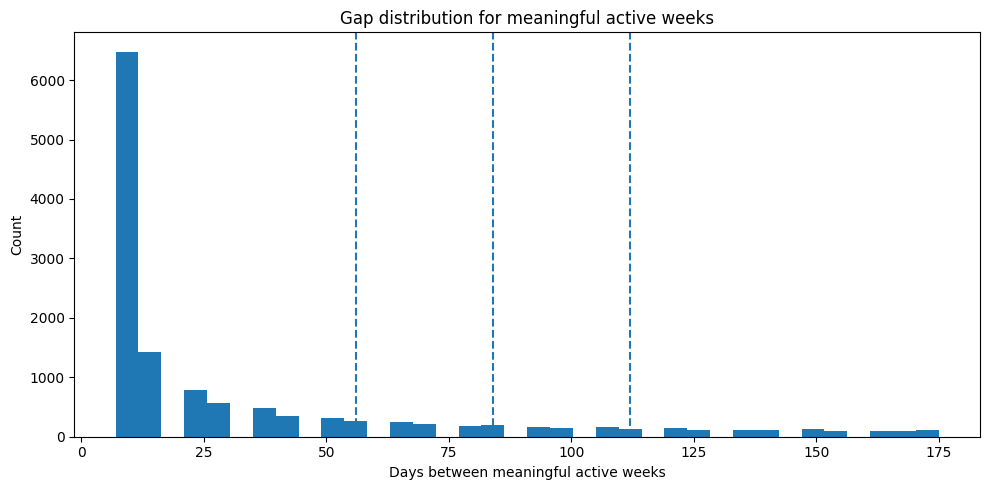

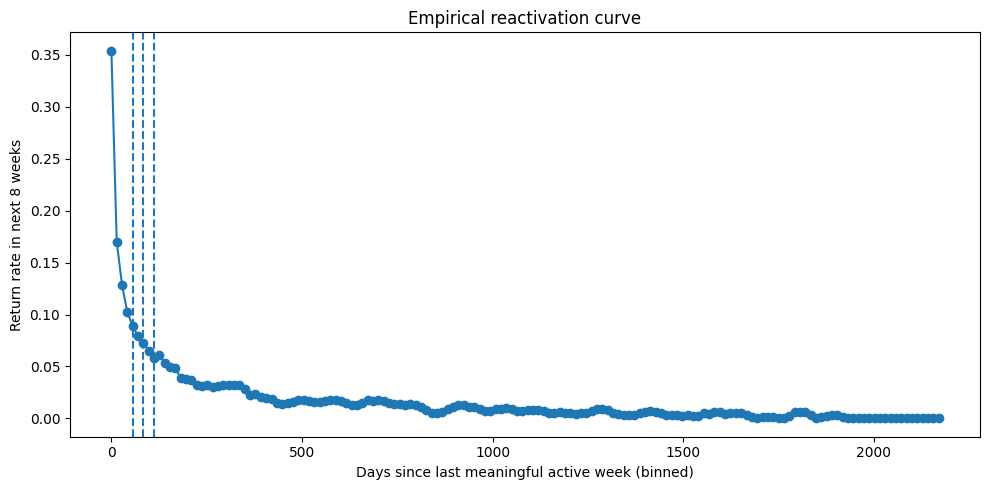

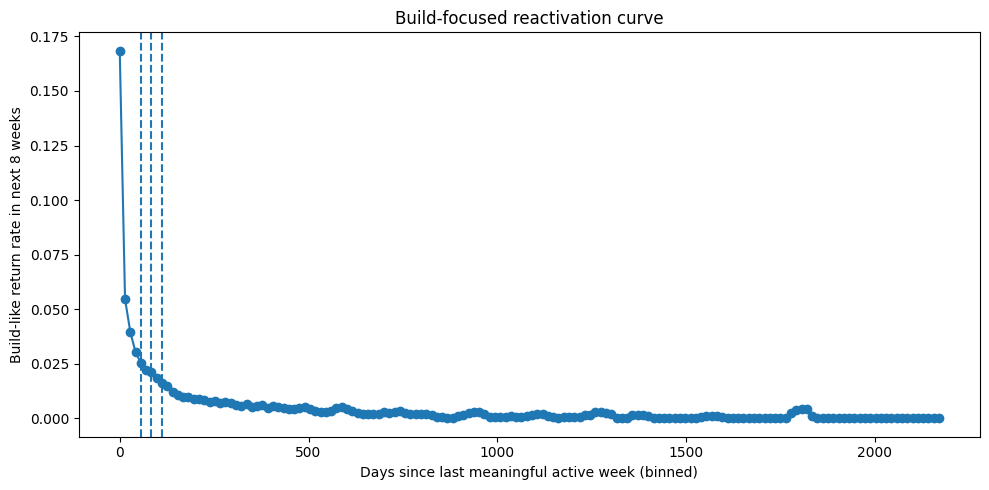

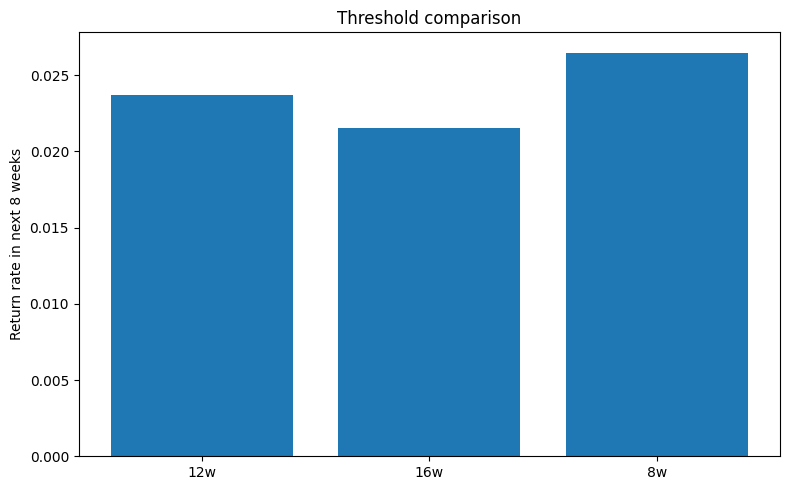

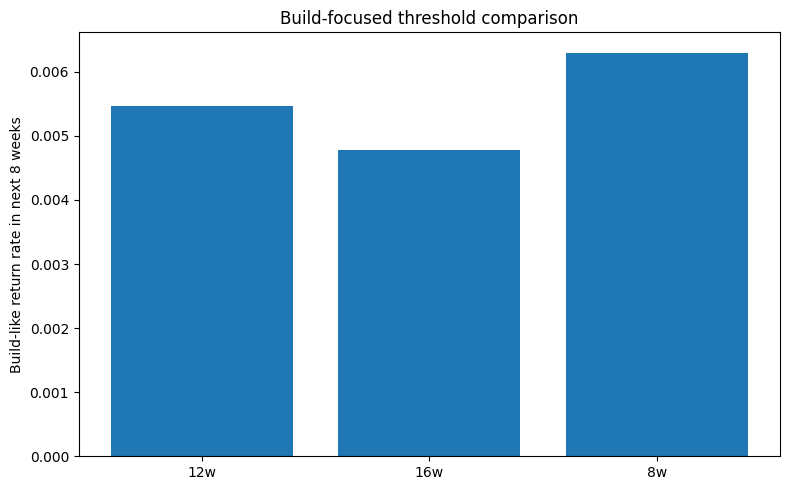

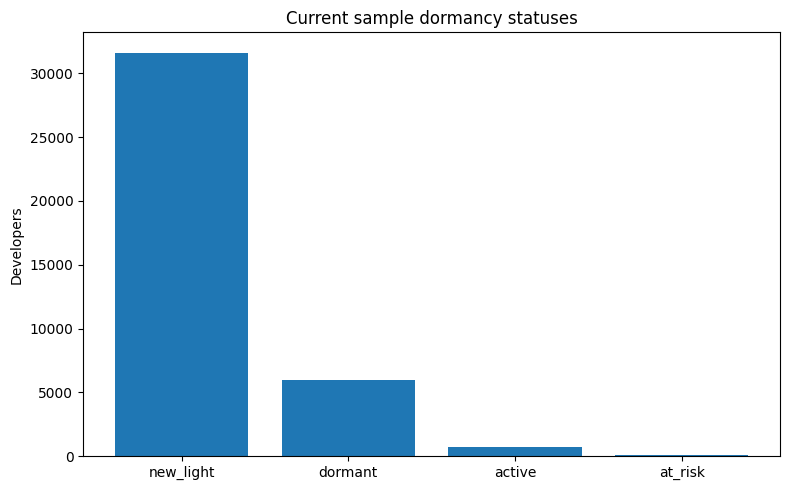

In [9]:
gaps = con.execute(f"""
    SELECT gap_days
    FROM meaningful_gap_dist_v1
    WHERE gap_days <= {PLOT_MAX_GAP_DAYS}
""").fetchdf()

curve = con.execute("""
    SELECT *
    FROM recency_curve_meaningful_v1
    ORDER BY recency_bin_days
""").fetchdf()

thresholds = con.execute("""
    SELECT *
    FROM threshold_eval_v1
    ORDER BY threshold
""").fetchdf()

status = con.execute("""
    SELECT dormancy_status, COUNT(*) AS developers
    FROM current_dev_dormancy_v1
    GROUP BY 1
    ORDER BY developers DESC
""").fetchdf()

# 1) Gap histogram
plt.figure(figsize=(10, 5))
plt.hist(gaps["gap_days"], bins=36)
plt.axvline(AT_RISK_DAYS, linestyle="--")
plt.axvline(DORMANT_DAYS, linestyle="--")
plt.axvline(112, linestyle="--")
plt.xlabel("Days between meaningful active weeks")
plt.ylabel("Count")
plt.title("Gap distribution for meaningful active weeks")
plt.tight_layout()
plt.show()

# 2) Reactivation curve
plt.figure(figsize=(10, 5))
plt.plot(curve["recency_bin_days"], curve["return_rate_next_8w"], marker="o")
plt.axvline(AT_RISK_DAYS, linestyle="--")
plt.axvline(DORMANT_DAYS, linestyle="--")
plt.axvline(112, linestyle="--")
plt.xlabel("Days since last meaningful active week (binned)")
plt.ylabel("Return rate in next 8 weeks")
plt.title("Empirical reactivation curve")
plt.tight_layout()
plt.show()

# 3) Build-focused reactivation curve
plt.figure(figsize=(10, 5))
plt.plot(curve["recency_bin_days"], curve["buildish_return_rate_next_8w"], marker="o")
plt.axvline(AT_RISK_DAYS, linestyle="--")
plt.axvline(DORMANT_DAYS, linestyle="--")
plt.axvline(112, linestyle="--")
plt.xlabel("Days since last meaningful active week (binned)")
plt.ylabel("Build-like return rate in next 8 weeks")
plt.title("Build-focused reactivation curve")
plt.tight_layout()
plt.show()

# 4) Threshold comparison
plt.figure(figsize=(8, 5))
plt.bar(thresholds["threshold"], thresholds["return_rate_next_8w"])
plt.ylabel("Return rate in next 8 weeks")
plt.title("Threshold comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(thresholds["threshold"], thresholds["buildish_return_rate_next_8w"])
plt.ylabel("Build-like return rate in next 8 weeks")
plt.title("Build-focused threshold comparison")
plt.tight_layout()
plt.show()

# 5) Current status counts
plt.figure(figsize=(8, 5))
plt.bar(status["dormancy_status"], status["developers"])
plt.ylabel("Developers")
plt.title("Current sample dormancy statuses")
plt.tight_layout()
plt.show()


In [10]:
con.execute("COPY threshold_eval_v1 TO 'Data/threshold_eval_v1.csv' (HEADER, DELIMITER ',')")
con.execute("COPY recency_curve_meaningful_v1 TO 'Data/recency_curve_meaningful_v1.csv' (HEADER, DELIMITER ',')")
con.execute("COPY current_dev_dormancy_v1 TO 'Data/current_dev_dormancy_v1.csv' (HEADER, DELIMITER ',')")
con.execute("COPY current_dev_dormancy_enriched_v1 TO 'Data/current_dev_dormancy_enriched_v1.csv' (HEADER, DELIMITER ',')")

print("Exports complete.")


IOException: IO Error: Cannot open file "Data/threshold_eval_v1.csv": No such file or directory